In [23]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from sklearn import datasets

In [24]:
iris = datasets.load_iris()
X = iris.data
target = iris.target
Y = to_categorical(target).astype("uint8")
# 0 => [1 0 0]
# 1 => [0 1 0]
# 2 => [0 0 1]

In [25]:
idx = 0
print(X[idx])
print(target[idx])
print(Y[idx])

[5.1 3.5 1.4 0.2]
0
[1 0 0]


In [26]:
model = keras.Sequential(
  [
    layers.Dense(3, activation="sigmoid", name="layer1", input_shape=(4,)),
    layers.Dense(3, activation="sigmoid", name="layer2"),
  ]
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 3)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27 (108.00 B)

 Trainable params: 27 (108.00 B)

 Non-trainable params: 0 (0.00 B)

In [27]:
y = model(X)
print(y[149])

tf.Tensor([0.77768236 0.5265726  0.46300015], shape=(3,), dtype=float32)


In [28]:
optimizer=tf.keras.optimizers.SGD(learning_rate=0.03)
loss=tf.keras.losses.MeanSquaredError()

model.compile(optimizer, loss)
history = model.fit(X, Y, epochs=500)

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3019 
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2999 
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2978 
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2959 
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2939 
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2919 
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2899 
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2880 
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2861 
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2842 
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2824 
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2805 
Epoch 13/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2787 
Epoch 14/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2769 
Epoch 15/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2751 
Epoch 16/500
5/5 ━

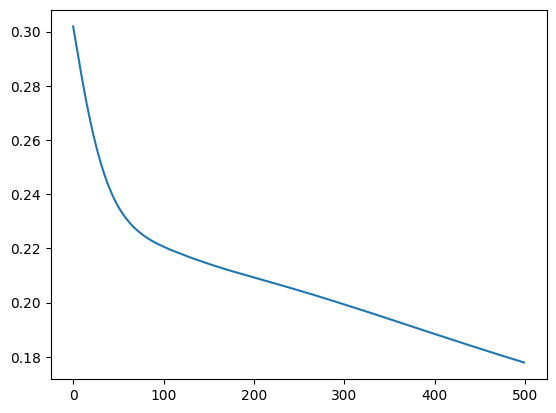

In [29]:
plt.plot(history.history['loss'])
plt.show()

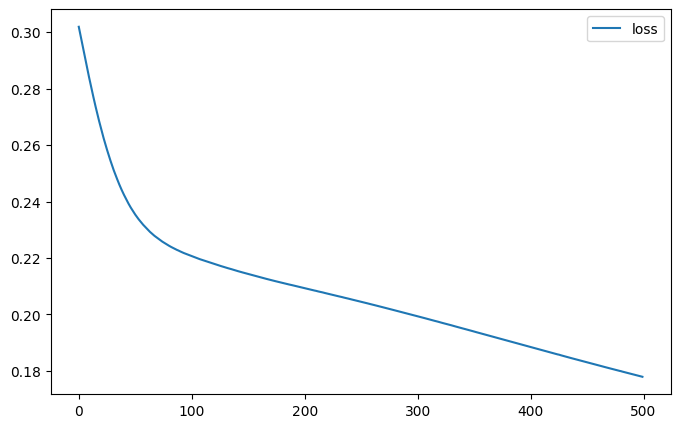

In [30]:
pd.DataFrame(history.history).plot(figsize=(8,5))
plt.show()

In [31]:
model.predict(np.array([[3,3,1,1]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


array([[0.45111406, 0.33778402, 0.30526426]], dtype=float32)

In [32]:
print("Loss inicial:", history.history["loss"][0])
print("Loss final:", history.history["loss"][-1])
print("Número de epochs:", len(history.history["loss"]))

Loss inicial: 0.3019113540649414
Loss final: 0.17792107164859772
Número de epochs: 500


# Red profunda: 4 x 3 x 3 x 3 x 3

In [11]:
model_deep = keras.Sequential(
    [
        layers.Dense(3,activation="sigmoid",name="layer1_deep",input_shape=(4,)),
        layers.Dense(3,activation="sigmoid",name="layer2_deep"),
        layers.Dense(3,activation="sigmoid",name="layer3_deep"),
        layers.Dense(3,activation="sigmoid",name="layer4_deep"),
    ]
)

model_deep.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1_deep (Dense)             │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2_deep (Dense)             │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer3_deep (Dense)             │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer4_deep (Dense)             │ (None, 3)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
optimizer_deep=tf.keras.optimizers.SGD(learning_rate=0.03)
loss_deep=tf.keras.losses.MeanSquaredError()

model_deep.compile(optimizer_deep, loss_deep)
history_deep = model_deep.fit(X, Y, epochs=500)

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2432  
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2427 
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2423 
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2418  
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2414 
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2409 
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2405 
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2401 
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2396 
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2392 
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2389 
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2385 
Epoch 13/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2381 
Epoch 14/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2377 
Epoch 15/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2374 
Epoch 16/500
5/5 

In [17]:
print("Loss final:", history_deep.history["loss"][-1])

Loss final: 0.2220918834209442


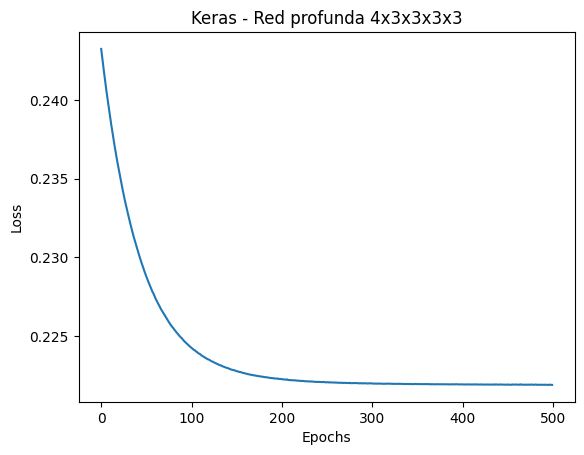

In [13]:
plt.plot(history_deep.history["loss"])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Keras - Red profunda 4x3x3x3x3")
plt.show()

In [19]:
model.predict(
    np.array([[3, 3, 1, 1]])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


array([[0.31751138, 0.31469715, 0.30679482]], dtype=float32)

In [33]:
print("Loss inicial profundo:", history_deep.history["loss"][0])
print("Loss final profundo:", history_deep.history["loss"][-1])
print("Número de epochs:", len(history_deep.history["loss"]))

Loss inicial profundo: 0.2432367503643036
Loss final profundo: 0.22188791632652283
Número de epochs: 500
